# Term Structure Construction, Swaps, and Lattice Option Pricing

Builds a SOFR discount curve from par quotes under three interpolation
assumptions, prices bonds and swaps off the bootstrapped curve, then
values American and barrier options on binomial and trinomial trees.

| Section | Topic | Methods |
|---|---|---|
| 1.1 | Discount curve bootstrapping | Piecewise-constant forwards, log-linear discount factors, and linear-continuous forwards, each solved by root finding |
| 1.2 | Swap pricing on the curve | Mark-to-market of a 10-year receiver swap, par rate, duration under a 10bp shock, forward-starting 5x10 and 10x10 swaps |
| 1.3 | Binomial trees | American and European puts with conditional discrete dividends, plus a double-barrier knockout variant |
| 1.4 | Trinomial tree | American and European puts, checked against CRR binomial prices at 3 to 1,000 steps |

All inputs are set inline and the notebook runs top to bottom with no
external data.

**Imports:**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import norm
from scipy.optimize import brentq
import math


## 1.1 Term Structure Construction
#### a) Estimate the discount factor assuming

**Given:** annual-pay SOFR par instruments quoted at 100 for tenors 1
through 40 years (the table is loaded in the next cell). A price of 100
means each quoted coupon is the par rate, so the discount factors $P(0,t)$
must satisfy the par condition

$$1 = c_T \sum_{t=1}^{T} P(0,t) + P(0,T)$$

at every quoted tenor $T$. Between quoted tenors the curve is
underdetermined, so each method below fixes an interpolation rule and
solves for the one unknown per interval that reprices the next quoted
instrument at par. All three methods agree over the first three years,
where tenors are consecutive and leave no interpolation freedom.

In [2]:
years = np.arange(0, 41)

data = pd.DataFrame({
    "Tenor":   [1, 2, 3, 5, 7, 10, 20, 30, 40],
    "Coupon":  [0.0364, 0.0340, 0.0335, 0.0339, 0.0349, 0.0366, 0.0397, 0.0393, 0.0382],
    "Freq":    [1]*9,
    "MktPrice":[100]*9
})

def par_bond_price(P, c, T):
    # Value of an annual-pay par bond
    pv = 0.0
    for t in range(1, T):
        pv += c * P[t]
    pv += (1.0 + c) * P[T]
    return pv

def fwd_from_df(P):
    f = np.zeros_like(P)
    for t in range(1, len(P)):
        f[t] = P[t-1] / P[t] - 1.0
    return f
data

,Tenor,Coupon,Freq,MktPrice
0,1,0.0364,1,100
1,2,0.0340,1,100
2,3,0.0335,1,100
3,5,0.0339,1,100
4,7,0.0349,1,100
5,10,0.0366,1,100
6,20,0.0397,1,100
7,30,0.0393,1,100
8,40,0.0382,1,100


#### Piecewise-constant forward rates

The per-year discount ratio $x$ is held constant inside each interval
between quoted tenors, equivalent to a constant continuously compounded
forward $f = -\ln x$:

$$P(0,t) = P(0,T_{prev}) \, x^{\,t - T_{prev}}, \qquad t \in (T_{prev}, T].$$

For each quoted tenor, `brentq` solves the par condition for the single
unknown $x$, reusing the already-bootstrapped discount factors for the
earlier coupons. The stored forward column holds $f = -\ln x$.

In [3]:
def bootstrap_pcf(data):
    P = np.zeros(41)
    fwd = np.zeros(41)
    P[0] = 1.0
    prev_T = 0

    for _, row in data.iterrows():
        T = int(row["Tenor"])
        c = float(row["Coupon"])
        if T == 1:
            P[1] = 1.0 / (1.0 + c)
            # cts forward: P(1) = P(0) * exp(-f * 1) hence  f = -ln(P(1))
            fwd[1] = -np.log(P[1])

            prev_T = 1
            continue

        P_prev = P[prev_T]
        known_df_sum = np.sum(P[1:prev_T+1])
        def residual(x):
            pv = c * known_df_sum
            for k in range(1, T - prev_T):
                pv += c * P_prev * (x**k)
            pv += (1.0 + c) * P_prev * (x**(T - prev_T))

            return pv - 1.0
        x_star = brentq(residual, 0.4, 1.1)
        f_const = -np.log(x_star)

        for t in range(prev_T + 1, T + 1):
            P[t] = P_prev * (x_star ** (t - prev_T))
            fwd[t] = f_const

        prev_T = T

    return P, fwd

#### Par rates are log-linear (LLDF)

$\ln P(0,t)$ is interpolated linearly between the last solved point and
the unknown endpoint $P(0,T)$:

$$P(0,t) = \exp\left[\ln P(0,T_{prev}) + \frac{\ln P(0,T) - \ln P(0,T_{prev})}{T - T_{prev}}\,(t - T_{prev})\right],$$

and `brentq` solves the par condition for $P(0,T)$ directly. Log-linear
discount factors imply a constant per-year ratio $P(0,t-1)/P(0,t)$ inside
each interval, so this produces the same discount curve as the
piecewise-constant bootstrap. The forward column here is quoted with
annual compounding, $F_t = P(0,t-1)/P(0,t) - 1$.

In [4]:
def bootstrap_lldf(data):
    P = np.zeros(41)
    P[0] = 1.0

    prev_T = 0

    for _, row in data.iterrows():
        T = int(row["Tenor"])
        c = float(row["Coupon"])

        if T == 1:
            P[1] = 1.0 / (1.0 + c)
            prev_T = 1
            continue
        P_prev = P[prev_T]
        known_years = np.arange(prev_T + 1, T)

        def residual(P_T):
            P_tmp = P.copy()

            # log-linear between (prev_T, P_prev) and (T, P_T)
            if T > prev_T + 1:
                slope = (np.log(P_T) - np.log(P_prev)) / (T - prev_T)
                for t in known_years:
                    P_tmp[t] = np.exp(np.log(P_prev) + slope * (t - prev_T))

            P_tmp[T] = P_T

            return par_bond_price(P_tmp, c, T) - 1.0

        low = 1e-12
        high = max(1e-15, P_prev * 0.999999999999999999)

        P_T_star = brentq(residual, low, high)
        if T > prev_T + 1:
            slope = (np.log(P_T_star) - np.log(P_prev)) / (T - prev_T)
            for t in known_years:
                P[t] = np.exp(np.log(P_prev) + slope * (t - prev_T))

        P[T] = P_T_star
        prev_T = T

    fwd = fwd_from_df(P)
    return P, fwd

#### Forward rates linear continuous

The annually compounded forward rate is linear in time across each
interval, starting from the previous interval's terminal forward
$f_{T_{prev}}$ and ending at an unknown $f_T$:

$$f_{T_{prev}+j} = f_{T_{prev}} + \left(f_T - f_{T_{prev}}\right)\frac{j}{T - T_{prev}}, \qquad P(0,t) = \frac{P(0,t-1)}{1 + f_t}.$$

`brentq` solves for the endpoint $f_T$ that reprices the quoted
instrument at par. Anchoring each segment at the previous endpoint makes
the forward curve continuous and piecewise linear rather than a step
function.

In [5]:
def bootstrap_lcf(data):
    P = np.zeros(41)
    fwd = np.zeros(41)
    P[0] = 1.0

    prev_T = 0

    for _, row in data.iterrows():
        T = int(row["Tenor"])
        c = float(row["Coupon"])

        if T == 1:
            # 1Y par bond: 1 = (1+c)P1  thus P1 = 1/(1+c), forward(0,1)=c
            P[1] = 1.0 / (1.0 + c)
            fwd[1] = P[0] / P[1] - 1.0  # equals c
            prev_T = 1
            continue

        f_start = fwd[prev_T]
        n = T - prev_T
        P_prev = P[prev_T]

        def residual(f_end):

            f_seg = np.zeros(n + 1)
            for j in range(1, n + 1):
                f_seg[j] = f_start + (f_end - f_start) * (j / n)

            P_tmp = P.copy()
            P_tmp[prev_T] = P_prev
            for j in range(1, n + 1):
                t = prev_T + j
                P_tmp[t] = P_tmp[t - 1] / (1.0 + f_seg[j])

            return par_bond_price(P_tmp, c, T) - 1.0

        f_end_star = brentq(residual, -0.05, 0.15)

        for j in range(1, n + 1):
            t = prev_T + j
            fwd[t] = f_start + (f_end_star - f_start) * (j / n)
            P[t] = P[t - 1] / (1.0 + fwd[t])

        prev_T = T

    return P, fwd


In [6]:
P_pcf,  f_pcf  = bootstrap_pcf(data)
P_lldf, f_lldf = bootstrap_lldf(data)
P_lcf,  f_lcf  = bootstrap_lcf(data)

curve_df = pd.DataFrame({
    "Year": years,
    "DF_PCF":  P_pcf,
    "Fwd_PCF": f_pcf,
    "DF_LLDF": P_lldf,
    "Fwd_LLDF": f_lldf,
    "DF_LCF":  P_lcf,
    "Fwd_LCF": f_lcf
})

print(curve_df)


    Year    DF_PCF   Fwd_PCF   DF_LLDF  Fwd_LLDF    DF_LCF   Fwd_LCF
0      0  1.000000  0.000000  1.000000  0.000000  1.000000  0.000000
1      1  0.964878  0.035753  0.964878  0.036400  0.964878  0.036400
2      2  0.935391  0.031038  0.935391  0.031524  0.935391  0.031524
3      3  0.905990  0.031936  0.905990  0.032451  0.905990  0.032451
4      4  0.875732  0.033968  0.875732  0.034552  0.876319  0.033860
5      5  0.846485  0.033968  0.846485  0.034552  0.846465  0.035268
6      6  0.815710  0.037033  0.815710  0.037727  0.816329  0.036917
7      7  0.786055  0.037033  0.786055  0.037727  0.786015  0.038567
8      8  0.754813  0.040556  0.754813  0.041390  0.755786  0.039997
9      9  0.724813  0.040556  0.724813  0.041390  0.725722  0.041426
10    10  0.696005  0.040556  0.696005  0.041390  0.695898  0.042856
11    11  0.666441  0.043405  0.666441  0.044361  0.667114  0.043148
12    12  0.638133  0.043405  0.638133  0.044361  0.639342  0.043439
13    13  0.611028  0.043405  0.61

####  b) Plot the forward rates and discount factors for all methods.

Two things stand out in the plots. The PCF and LLDF discount factors sit
exactly on top of each other, identical to the sixth decimal in the table
above, because log-linear interpolation of discount factors is the same
assumption as a constant forward per interval; their forward panels
differ only in quoting convention, continuous versus annual compounding.
The LCF forwards ramp smoothly instead of stepping, which reshapes the
interior discount factors, so beyond year 3 the LCF curve deviates
slightly from the other two while still repricing every quoted instrument
at par.

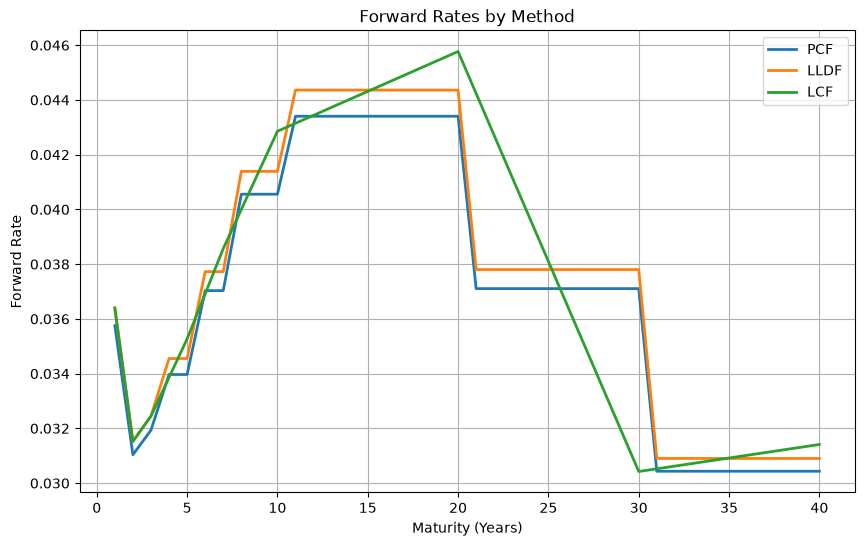

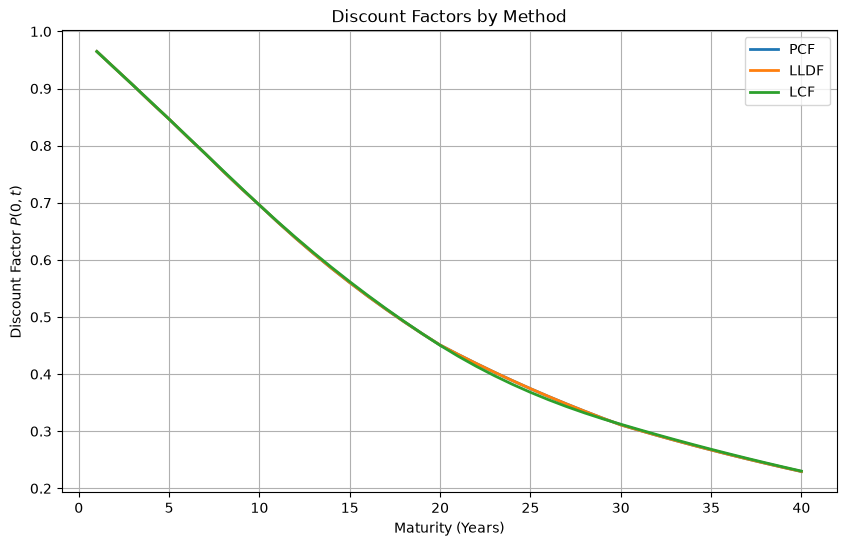

In [7]:
plt.style.use("default")
plt.figure(figsize=(10, 6))
plt.plot(curve_df["Year"][1:], curve_df["Fwd_PCF"][1:], label="PCF", linewidth=2)
plt.plot(curve_df["Year"][1:], curve_df["Fwd_LLDF"][1:], label="LLDF", linewidth=2)
plt.plot(curve_df["Year"][1:], curve_df["Fwd_LCF"][1:], label="LCF", linewidth=2)
plt.xlabel("Maturity (Years)")
plt.ylabel("Forward Rate")
plt.title("Forward Rates by Method")
plt.legend()
plt.grid(True)

plt.show()

plt.figure(figsize=(10, 6))
plt.plot(curve_df["Year"][1:], curve_df["DF_PCF"][1:],  label="PCF",  linewidth=2)
plt.plot(curve_df["Year"][1:], curve_df["DF_LLDF"][1:], label="LLDF", linewidth=2)
plt.plot(curve_df["Year"][1:], curve_df["DF_LCF"][1:],  label="LCF",  linewidth=2)
plt.xlabel("Maturity (Years)")
plt.ylabel("Discount Factor $P(0,t)$")
plt.title("Discount Factors by Method")
plt.legend()
plt.grid(True)

plt.show()

#### c) What are the values and durations of a 5, 10, 15, 20, 25, and 30-year annual pay par bonds with coupons from the above table for the three methods?

Coupons for the unquoted 15 and 25 year maturities are linearly
interpolated from the quoted table. Each bond is priced off each curve
with face value 100, and its Macaulay duration is computed from the same
cashflow PVs:

$$V = \sum_{t=1}^{T-1} 100\,c\,P(0,t) + 100\,(1+c)\,P(0,T), \qquad D = \frac{1}{V}\sum_{t=1}^{T} t\cdot \mathrm{PV}_t.$$

Bonds at quoted tenors come back at exactly 100 under all three curves, a
direct consistency check on the bootstrap, while the interpolated 15 and
25 year coupons sit slightly off par.

In [8]:
maturities = [5, 10, 15, 20, 25, 30]
coupons = np.interp(
    np.arange(1, 41),
    data["Tenor"].values,
    data["Coupon"].values
)
def coupon_for_T(T):
    return coupons[T - 1]

def bond_value_and_duration(P, c, T, face=100):
    price = 0.0
    weighted_time = 0.0

    for t in range(1, T):
        cf = c * face
        pv = cf * P[t]
        price += pv
        weighted_time += t * pv

    # final payment
    cf_T = (1.0 + c) * face
    pv_T = cf_T * P[T]
    price += pv_T
    weighted_time += T * pv_T

    duration = weighted_time / price
    return price, duration

results = []
for T in maturities:
    c = coupon_for_T(T)
    price_pcf, dur_pcf   = bond_value_and_duration(P_pcf,  c, T)
    price_lldf, dur_lldf = bond_value_and_duration(P_lldf, c, T)
    price_lcf, dur_lcf   = bond_value_and_duration(P_lcf,  c, T)
    results.append({
        "Maturity": T,
        "Value PCF":  price_pcf,
        "Duration PCF":    dur_pcf,
        "Value LLDF": price_lldf,
        "Duration LLDF":   dur_lldf,
        "Value LCF":  price_lcf,
        "Duration LCF":    dur_lcf
    })

results_df = pd.DataFrame(results)
print(results_df.round(2))

   Maturity  Value PCF  Duration PCF  Value LLDF  Duration LLDF  Value LCF  \
0         5     100.00          4.68      100.00           4.68     100.00   
1        10     100.00          8.54      100.00           8.54     100.00   
2        15      99.39         11.63       99.39          11.63      99.58   
3        20     100.00         14.06      100.00          14.06     100.00   
4        25     100.07         16.19      100.07          16.19      99.37   
5        30     100.00         17.98      100.00          17.98     100.00   

   Duration LCF  
0          4.68  
1          8.54  
2         11.64  
3         14.05  
4         16.13  
5         17.98  


## 1.2 Swaps
Have a swap with the following characteristics:
- c = Receive 3% fixed and pay float (Annual compound).
- Fixed and Float pay annually.
- T = 10-year maturity
- L = Notional is $1,000,000
#### a) What is the value of the swap?

The floating leg resets to the annual forwards implied by the LLDF curve,
$F_t = P(0,t-1)/P(0,t) - 1$, so each payment date nets fixed against
forward:

$$V = L \sum_{t=1}^{10} \left(c - F_t\right) P(0,t).$$

The forwards sit above the 3% coupon at every payment date, which is why
receiving fixed here carries negative value.

In [9]:
L = 1000000
c = 0.03
T = 10
F = curve_df["Fwd_LLDF"].values

V_swap = L * np.sum(
    (c - F[1:T+1]) * P_lldf[1:T+1]
)
print(f"Value of a Swap = ${V_swap.round(2)}")

Value of a Swap = $-54818.75


#### b) What is the par swap rate?

Because $F_t\,P(0,t) = P(0,t-1) - P(0,t)$, the floating leg telescopes to
$1 - P(0,10)$, and setting $V = 0$ gives

$$c^{\ast} = \frac{1 - P(0,10)}{\sum_{t=1}^{10} P(0,t)}.$$

In [10]:
par_swap_rate = (1 - P_lldf[T]) / np.sum(P_lldf[1:T+1])
print(f"Par swap rate = {100 * par_swap_rate:.3f}%")

Par swap rate = 3.660%


#### c) What is the swap duration if all rates are up 10bp?

All zero rates shift up 10bp with continuous compounding,
$P^{\text{shock}}(0,t) = P(0,t)\,e^{-0.001\,t}$, forwards are rebuilt
from the shocked curve, and the swap is revalued. The reported duration
is the relative value change per unit of shift,

$$D = \frac{V^{\text{shock}} - V_0}{V_0 \cdot \Delta y}.$$

Scaling by the swap's own value makes the number large: a swap near par
has a small base value relative to notional, so even a modest dollar
change is a big multiple of it.

In [11]:
T = 10
dy = 0.001
V_0 = V_swap
years = np.arange(0,41)
# change in df curve from shock in y
P_shock = P_lldf.copy() * np.exp(-dy * years)

# change in fwd curve from shock in y
F_shock = np.zeros(T+1)
for t in range(1, T+1):
    F_shock[t] = P_shock[t-1] / P_shock[t] - 1

V_shock = L * np.sum((c-F_shock[1:T+1])*P_shock[1:T+1])
swap_duration =  (V_shock - V_0) / (V_0 * dy)

print(f"Swap value after all rates are up 10bp =  {V_shock:.2f}")
print(f"Swap duration after all rates are up 10bp = {swap_duration:.2f}")



Swap value after all rates are up 10bp =  -63035.97
Swap duration after all rates are up 10bp = 149.90


#### d) What is the value of a forward starting swap starting in 5 years for 10-years (5x10) where you receive a fixed coupon (Annual) of 4% and pay floating?

For a receiver swap covering years 6 through 15 at a 4% fixed coupon, the
fixed leg discounts the coupons over that window and the floating leg
telescopes between the start and end dates:

$$V_{5\times 10} = L\,c_{\text{fwd}} \sum_{t=6}^{15} P(0,t) \;-\; L\left[P(0,5) - P(0,15)\right].$$

In [12]:
c_fwd = 0.04
start_year = 5
end_year = 15

pv_fixed = L * c_fwd * np.sum(P_lldf[start_year+1:end_year+1])
pv_float = L * (P_lldf[start_year] - P_lldf[end_year])
V_5x10_swap = pv_fixed - pv_float

print(f"Value of 5x10 receive-fixed swap = ${V_5x10_swap:,.2f}")

Value of 5x10 receive-fixed swap = $-12,731.11


#### e) What is the par forward 10-year swap rate starting in 10-years?

The same telescoping logic reads the forward par rate directly off the
curve:

$$c^{\ast}_{10\times 10} = \frac{P(0,10) - P(0,20)}{\sum_{t=11}^{20} P(0,t)}.$$

In [13]:
par_10x10 = (P_lldf[start_year] - P_lldf[end_year]) / np.sum(P_lldf[start_year+1:end_year+1])

print(f"Par forward 10x10 swap rate = {100 * par_10x10:.3f}%")

Par forward 10x10 swap rate = 4.186%


## 1.3 Binomial Model
- S_0 = 100
- K = 100
- Rf = 3%
- $\sigma$ = 20%;
- T = 2 Year Semi-annual time steps (4 Time Steps)
- USD 2.00 Dividend paid in 6 months if S>100
- USD 2.50 Dividend paid in 18 months if S>100

#### a) European and American Value of a Put option?

A CRR lattice with semi-annual steps:

$$u = e^{\sigma\sqrt{\Delta t}}, \qquad d = e^{-\sigma\sqrt{\Delta t}}, \qquad p = \frac{e^{r\Delta t} - d}{u - d}, \qquad \Delta t = 0.5.$$

At the 6 and 18 month steps, the move is applied first and then, if the
moved price exceeds 100, the cash dividend is subtracted. The cash drop
breaks recombination, so the tree is tracked path by path. Backward
induction discounts the expected value one step at a time, and the
American put additionally takes $\max(\text{continuation},\; K - S)$ at
every node.

In [14]:
# build stock tree
def stock_tree(S_0, rf, sigma, T, N, div_schedule, div_threshold=100):
    dt = T / N
    u = np.exp(sigma * np.sqrt(dt))
    d = np.exp(-sigma * np.sqrt(dt))
    p = (np.exp(rf * dt) - d) / (u - d)
    df = np.exp(-rf * dt)

    S_tree = {0: {"": S_0}}
    for t in range(1, N + 1):
        S_tree[t] = {}
        for path, S_prev in S_tree[t - 1].items():

            # Down move
            Sd = S_prev * d
            if t in div_schedule and Sd > div_threshold:
                Sd -= div_schedule[t]
            S_tree[t][path + "D"] = Sd

            # Up move
            Su = S_prev * u
            if t in div_schedule and Su > div_threshold:
                Su -= div_schedule[t]
            S_tree[t][path + "U"] = Su

    return S_tree, u, d, p, df


# build European put tree
def euro_put_values(S_tree,K,p,df,N):
    V = {}

    # Terminal payoffs
    V[N] = {}
    for path, S_T in S_tree[N].items():
        V[N][path] = max(K - S_T, 0)

    # Backward induction
    for t in range(N - 1, -1, -1):
        V[t] = {}
        for path in S_tree[t]:
            V[t][path] = df * (
                p * V[t + 1][path + "U"] +
                (1 - p) * V[t + 1][path + "D"]
            )

    return V

# build American put tree
def american_put_values(S_tree, K, p, df, N):
    V = {}

    # Terminal payoffs
    V[N] = {}
    for path, S_T in S_tree[N].items():
        V[N][path] = max(K - S_T, 0)

    # Backward induction with early exercise
    for t in range(N - 1, -1, -1):
        V[t] = {}
        for path, S_t in S_tree[t].items():
            continuation = df * (
                p * V[t + 1][path + "U"] +
                (1 - p) * V[t + 1][path + "D"]
            )
            exercise = max(K - S_t, 0)
            V[t][path] = max(continuation, exercise)

    return V

# graph binomial tree
def plot_binomial_tree(tree, V_euro, V_amer):
    import networkx as nx
    import matplotlib.pyplot as plt

    G = nx.DiGraph()
    labels = {}
    pos = {}

    y_gap = 2.5
    x_gap = 2.0
    for t, nodes in tree.items():
        paths = sorted(nodes.keys())
        n = len(paths)
        y_start = -y_gap * (n - 1) / 2  # center each layer

        for i, path in enumerate(paths):
            node = (t, path)
            G.add_node(node)
            x = t * x_gap
            y = y_start + i * y_gap
            pos[node] = (x, y)
            S = nodes[path]
            labels[node] = (
                f"S={S:.1f}\n"
                f"E={V_euro[t][path]:.2f}\n"
                f"A={V_amer[t][path]:.2f}"
            )
            if t > 0:
                parent = (t - 1, path[:-1])
                G.add_edge(parent, node)

    plt.figure(figsize=(40, 35))
    nx.draw(G,pos,
        node_size=15000,
        node_color='orange',
        edge_color="black",
        linewidths=1.2,
        with_labels=False
    )
    nx.draw_networkx_labels(G,pos, labels,
        font_size=20,
        font_weight="bold",
        font_color="black"
    )
    plt.axis("off")
    plt.show()

p = 0.5180
u = 1.1519
d = 0.8681
df = 0.9851
European Put = $ 8.3406
American Put = $ 9.3496


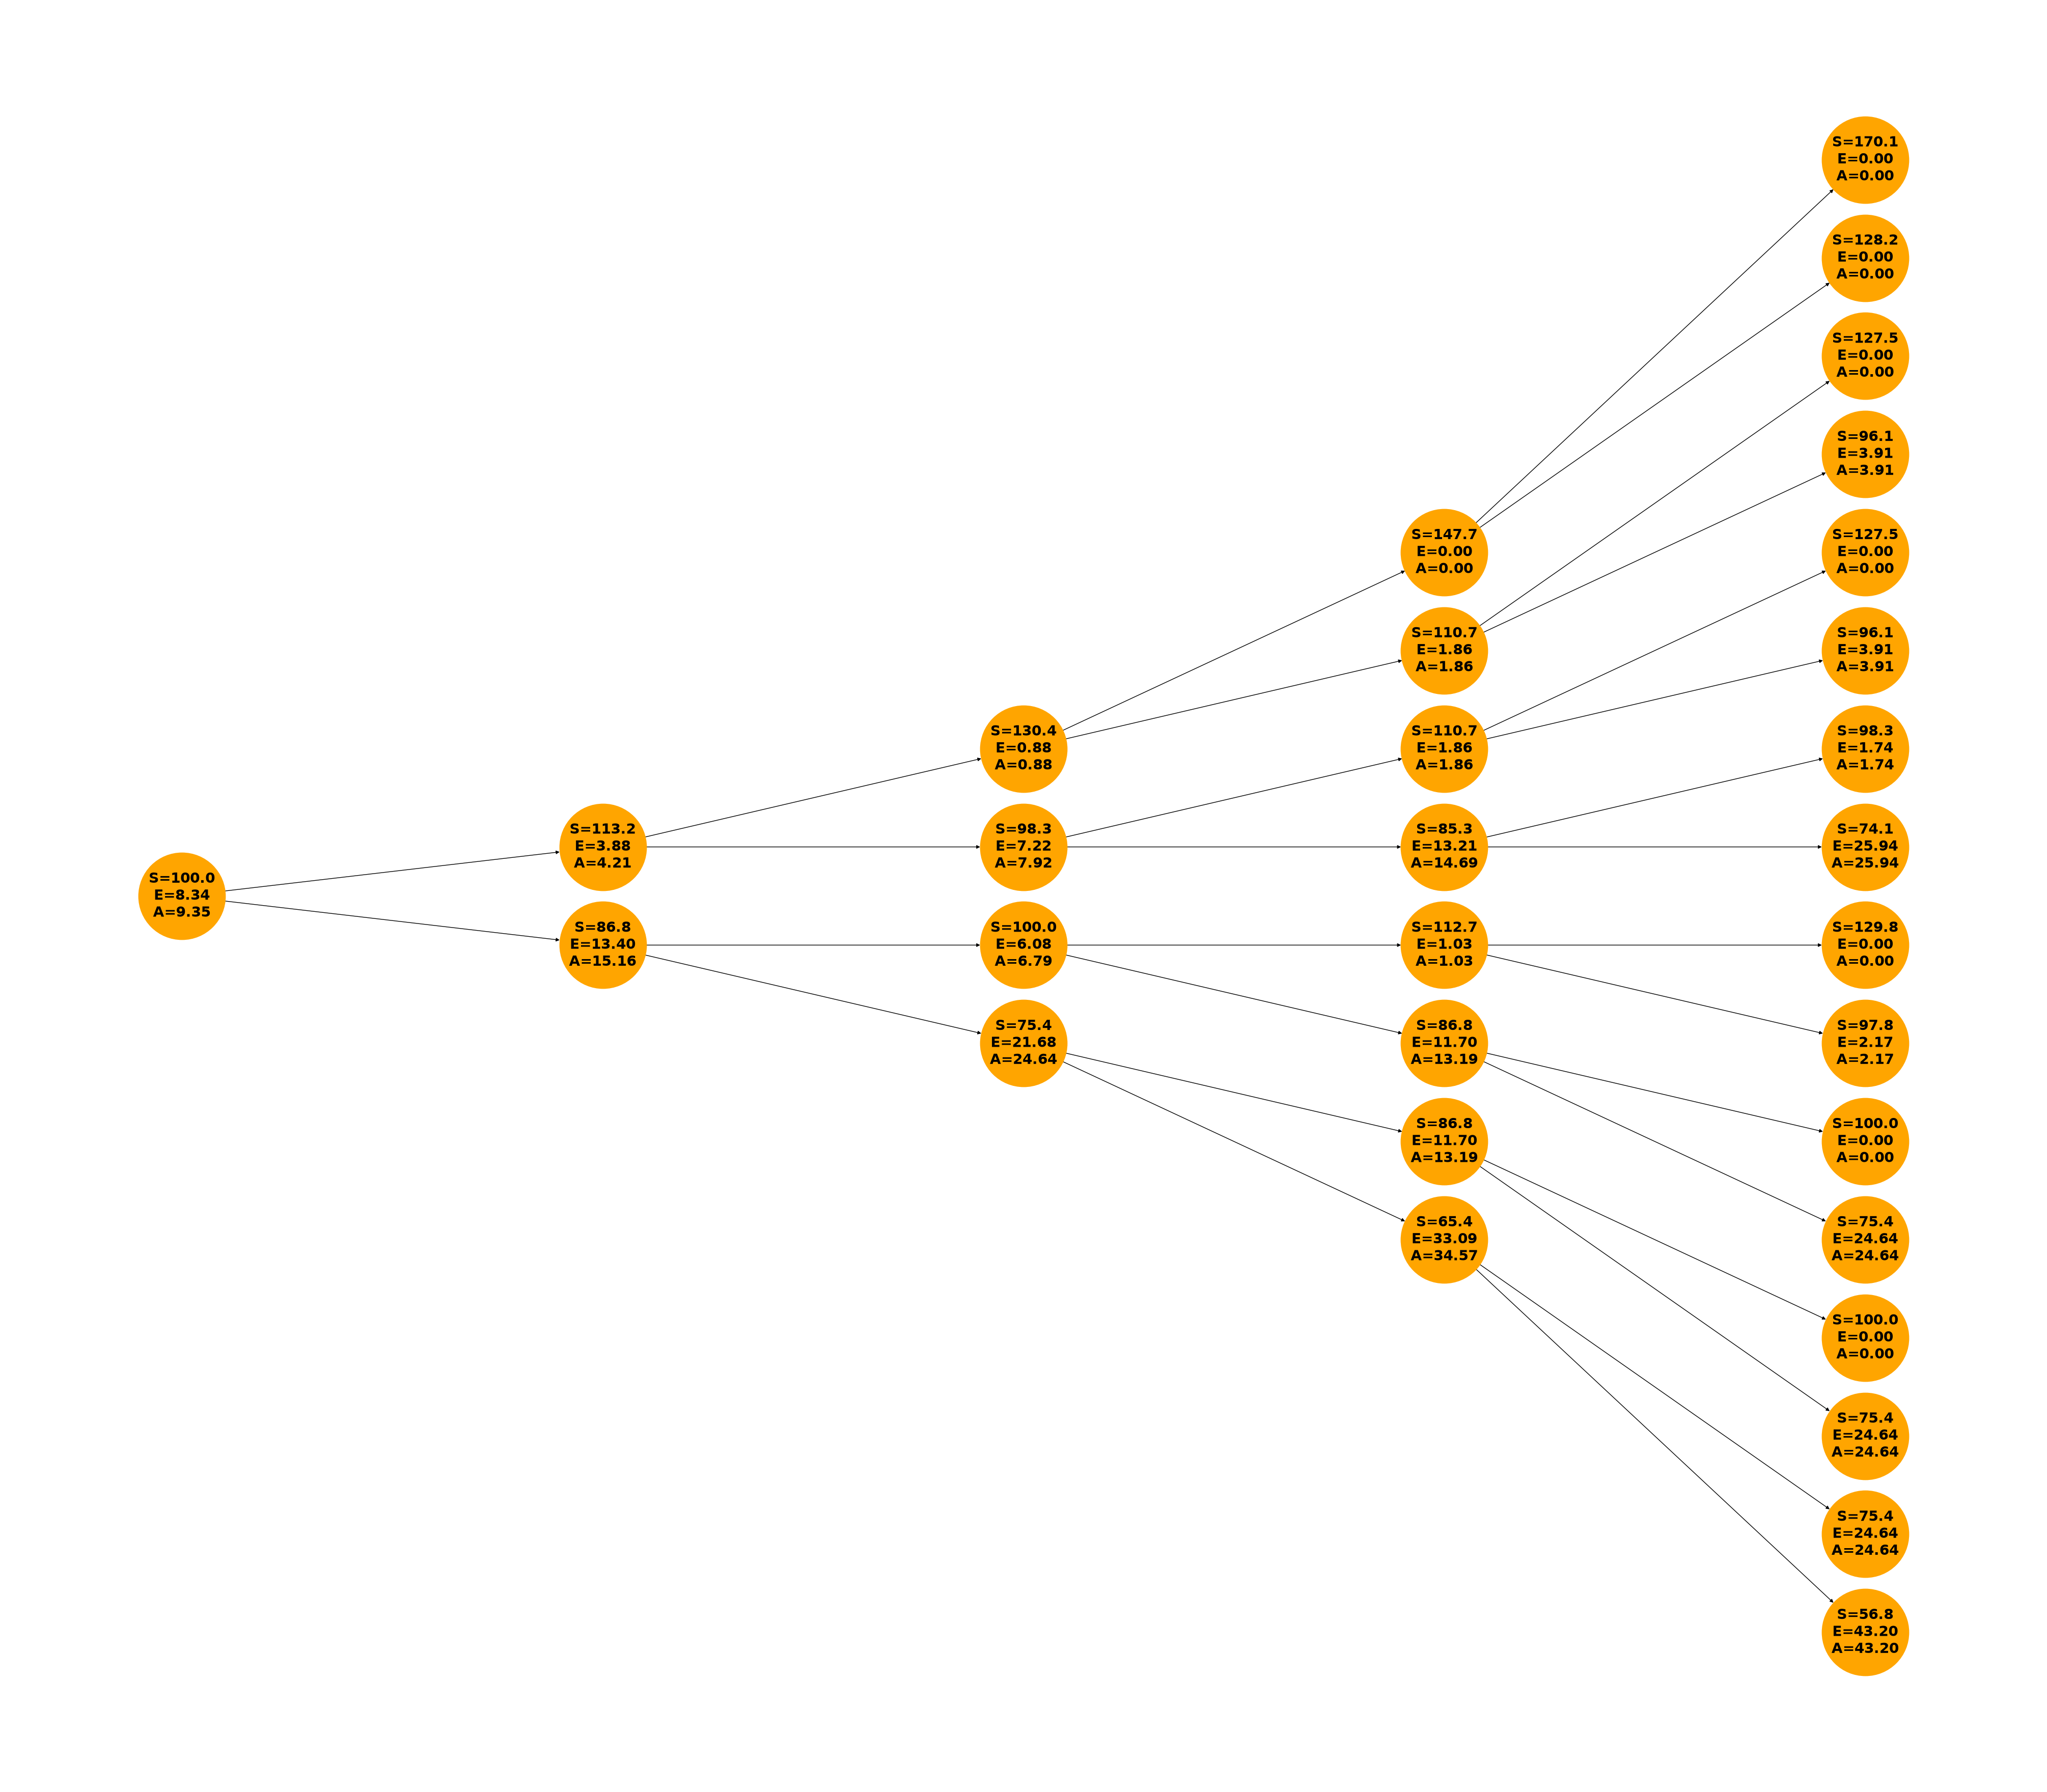

In [15]:
S_0 = 100
K = 100
rf = 0.03
sigma = 0.2
T = 2
N = 4
div_schedule = { 1: 2.0, 3: 2.5}

S_tree, u, d, p, df = stock_tree(S_0, rf, sigma, T, N, div_schedule)
V_euro = euro_put_values(S_tree, K, p, df, N)
V_american = american_put_values(S_tree, K, p, df, N)

print(f"p = {p:.4f}")
print(f"u = {u:.4f}")
print(f"d = {d:.4f}")
print(f"df = {df:.4f}")

print(f"European Put = $", round(V_euro[0][""], 4))
print("American Put = $", round(V_american[0][""], 4))

plot_binomial_tree(S_tree, V_euro, V_american)


#### b) Option value if initial stock price (S) is 110?

Same lattice rebuilt with the initial price at 110: the put starts
further out of the money and both values fall.

p = 0.5180
u = 1.1519
d = 0.8681
df = 0.9851
European Put = $ 5.7167
American Put = $ 5.8761


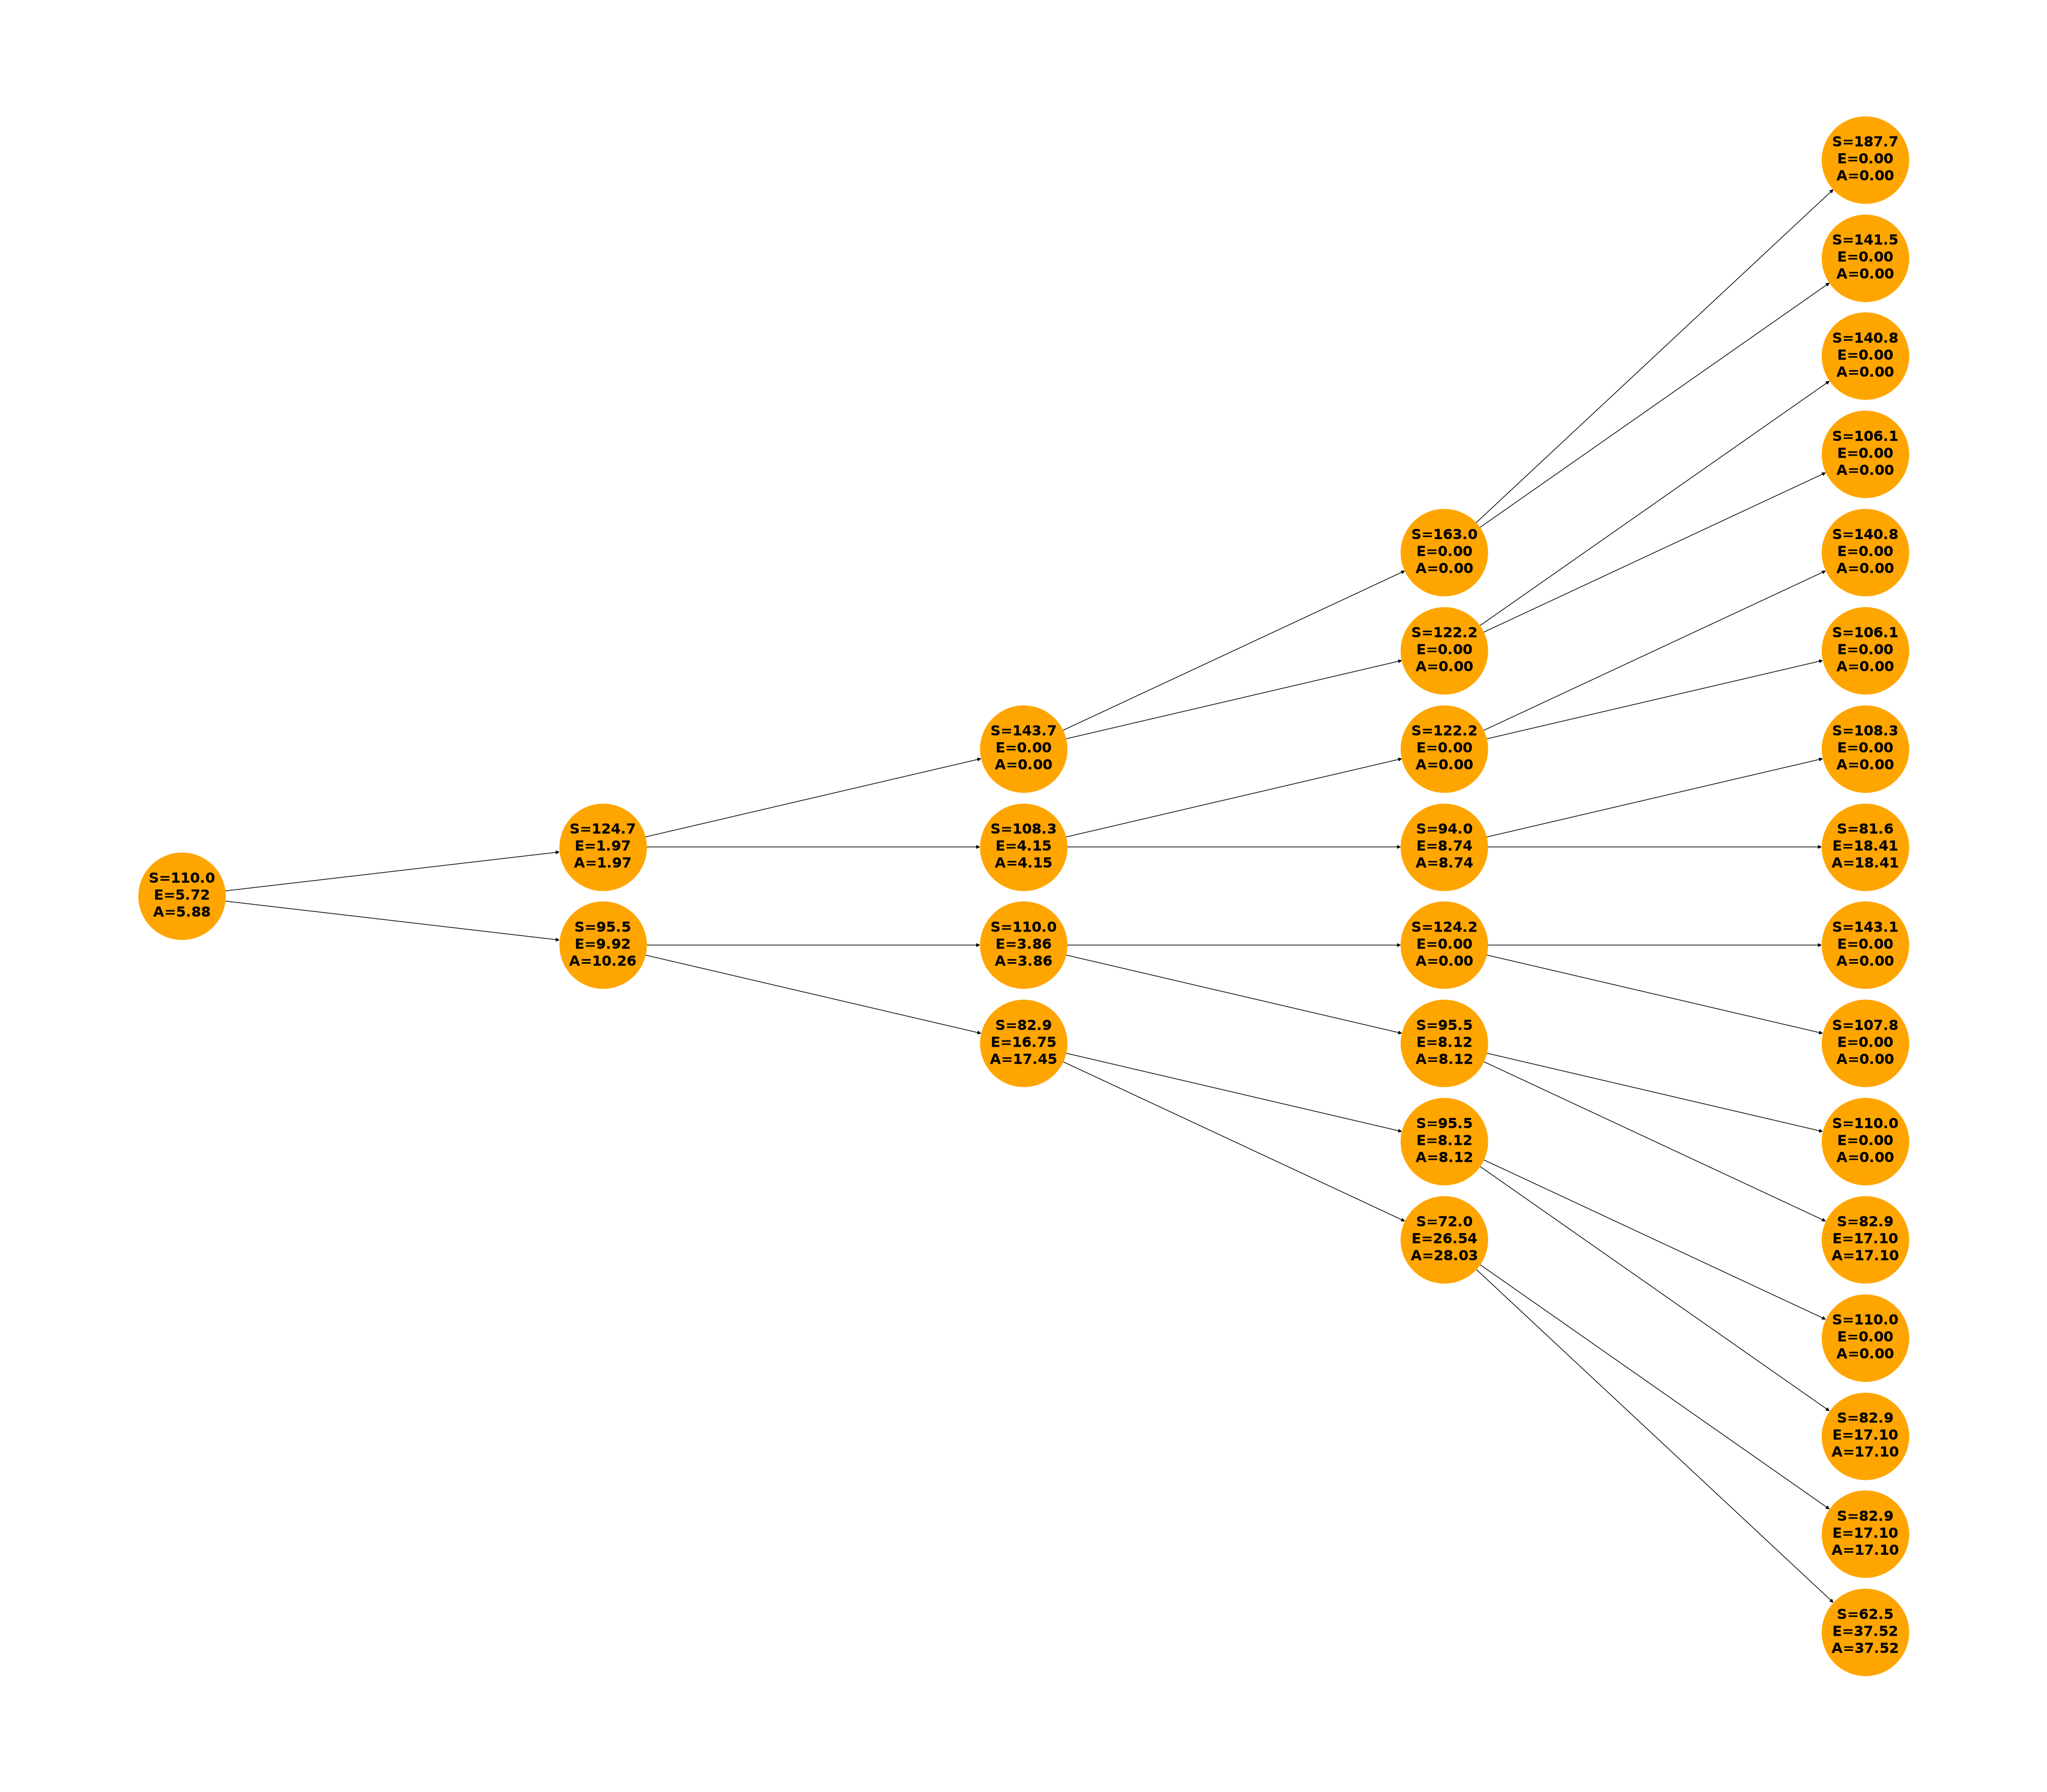

In [16]:
S_0 = 110

S_tree, u, d, p, df = stock_tree(S_0, rf, sigma, T, N, div_schedule)
V_euro = euro_put_values(S_tree, K, p, df, N)
V_american = american_put_values(S_tree, K, p, df, N)

print(f"p = {p:.4f}")
print(f"u = {u:.4f}")
print(f"d = {d:.4f}")
print(f"df = {df:.4f}")

print(f"European Put = $", round(V_euro[0][""], 4))
print("American Put = $", round(V_american[0][""], 4))

plot_binomial_tree(S_tree, V_euro, V_american)


#### c) Options value if initial risk-free rate (Rf)is 3.30%?

Same lattice with the rate at 3.3%: the risk-neutral probability $p$
rises and the per-step discount factor tightens, lifting the risk-neutral
drift, so the put is worth less than in part a.

p = 0.5233
u = 1.1519
d = 0.8681
df = 0.9836
European Put = $ 8.0689
American Put = $ 9.153


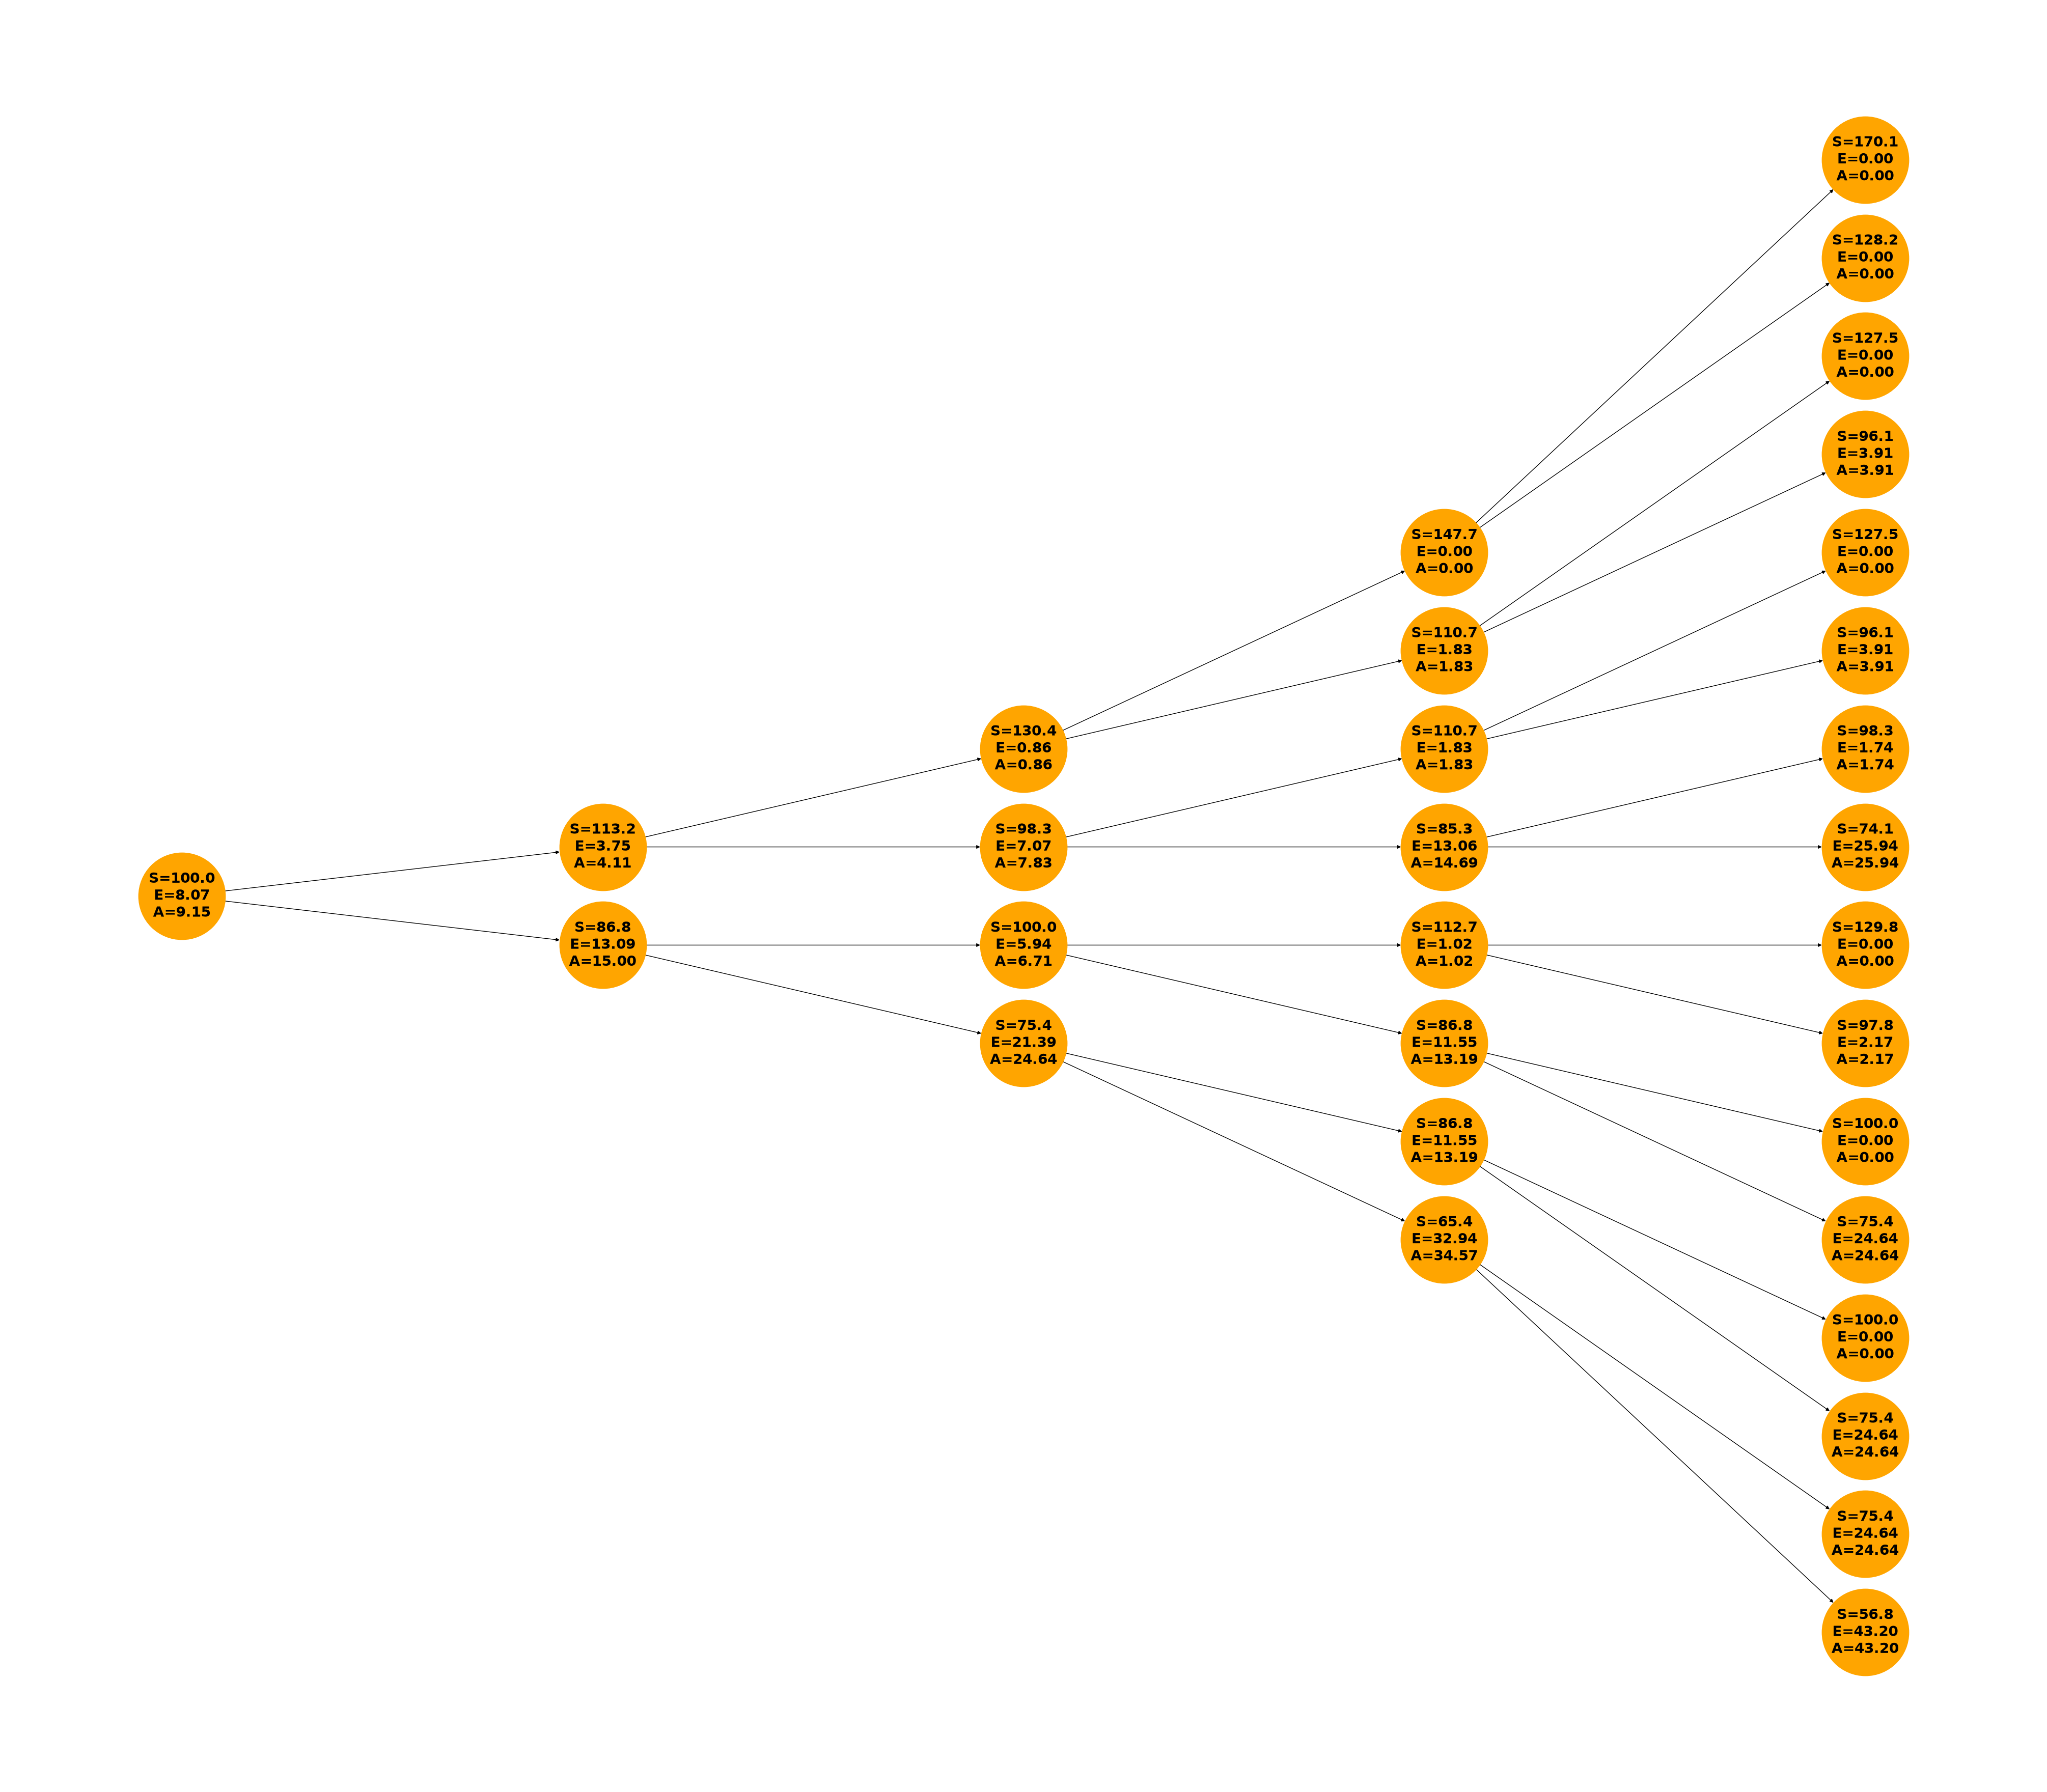

In [17]:
S_0 = 100
rf = 0.033

S_tree, u, d, p, df = stock_tree(S_0, rf, sigma, T, N, div_schedule)
V_euro = euro_put_values(S_tree, K, p, df, N)
V_american = american_put_values(S_tree, K, p, df, N)

print(f"p = {p:.4f}")
print(f"u = {u:.4f}")
print(f"d = {d:.4f}")
print(f"df = {df:.4f}")

print(f"European Put = $", round(V_euro[0][""], 4))
print("American Put = $", round(V_american[0][""], 4))

plot_binomial_tree(S_tree, V_euro, V_american)


## d) Calculate the American and European values for Put option that is knocked out if the stock price rises above 130 or if the stock price falls below 70.

The same path tree is revalued with a knockout test at every node,
including expiry: the option stays alive only while $70 \le S \le 130$,
and any node outside the band carries zero value. The European put loses
roughly half its value because the deep-in-the-money region overlaps the
lower barrier. The American put barely moves relative to the vanilla
case: early exercise collects intrinsic value at nodes just above 70, one
step before a further down move would knock the option out.

In [18]:
def euro_put_KO_values(S_tree, K, p, df, N, L, U):
    V = {N: {}}
    # terminal
    for path, S_T in S_tree[N].items():
        alive = (L <= S_T <= U)
        V[N][path] = max(K - S_T, 0.0) if alive else 0.0

    # backward induction with KO at every node
    for t in range(N - 1, -1, -1):
        V[t] = {}
        for path, S_t in S_tree[t].items():
            alive = (L <= S_t <= U)
            if not alive:
                V[t][path] = 0.0
            else:
                V[t][path] = df * (p * V[t + 1][path + "U"] + (1 - p) * V[t + 1][path + "D"])
    return V

def american_put_KO_values(S_tree, K, p, df, N, L, U):
    V = {N: {}}
    # terminal
    for path, S_T in S_tree[N].items():
        alive = (L <= S_T <= U)
        V[N][path] = max(K - S_T, 0.0) if alive else 0.0

    # backward induction with KO + early exercise
    for t in range(N - 1, -1, -1):
        V[t] = {}
        for path, S_t in S_tree[t].items():
            alive = (L <= S_t <= U)
            if not alive:
                V[t][path] = 0.0
            else:
                cont = df * (p * V[t + 1][path + "U"] + (1 - p) * V[t + 1][path + "D"])
                exer = max(K - S_t, 0.0)
                V[t][path] = max(cont, exer)
    return V


 European Knock-Out Put = $4.5684
American Knock-Out Put = $9.1203


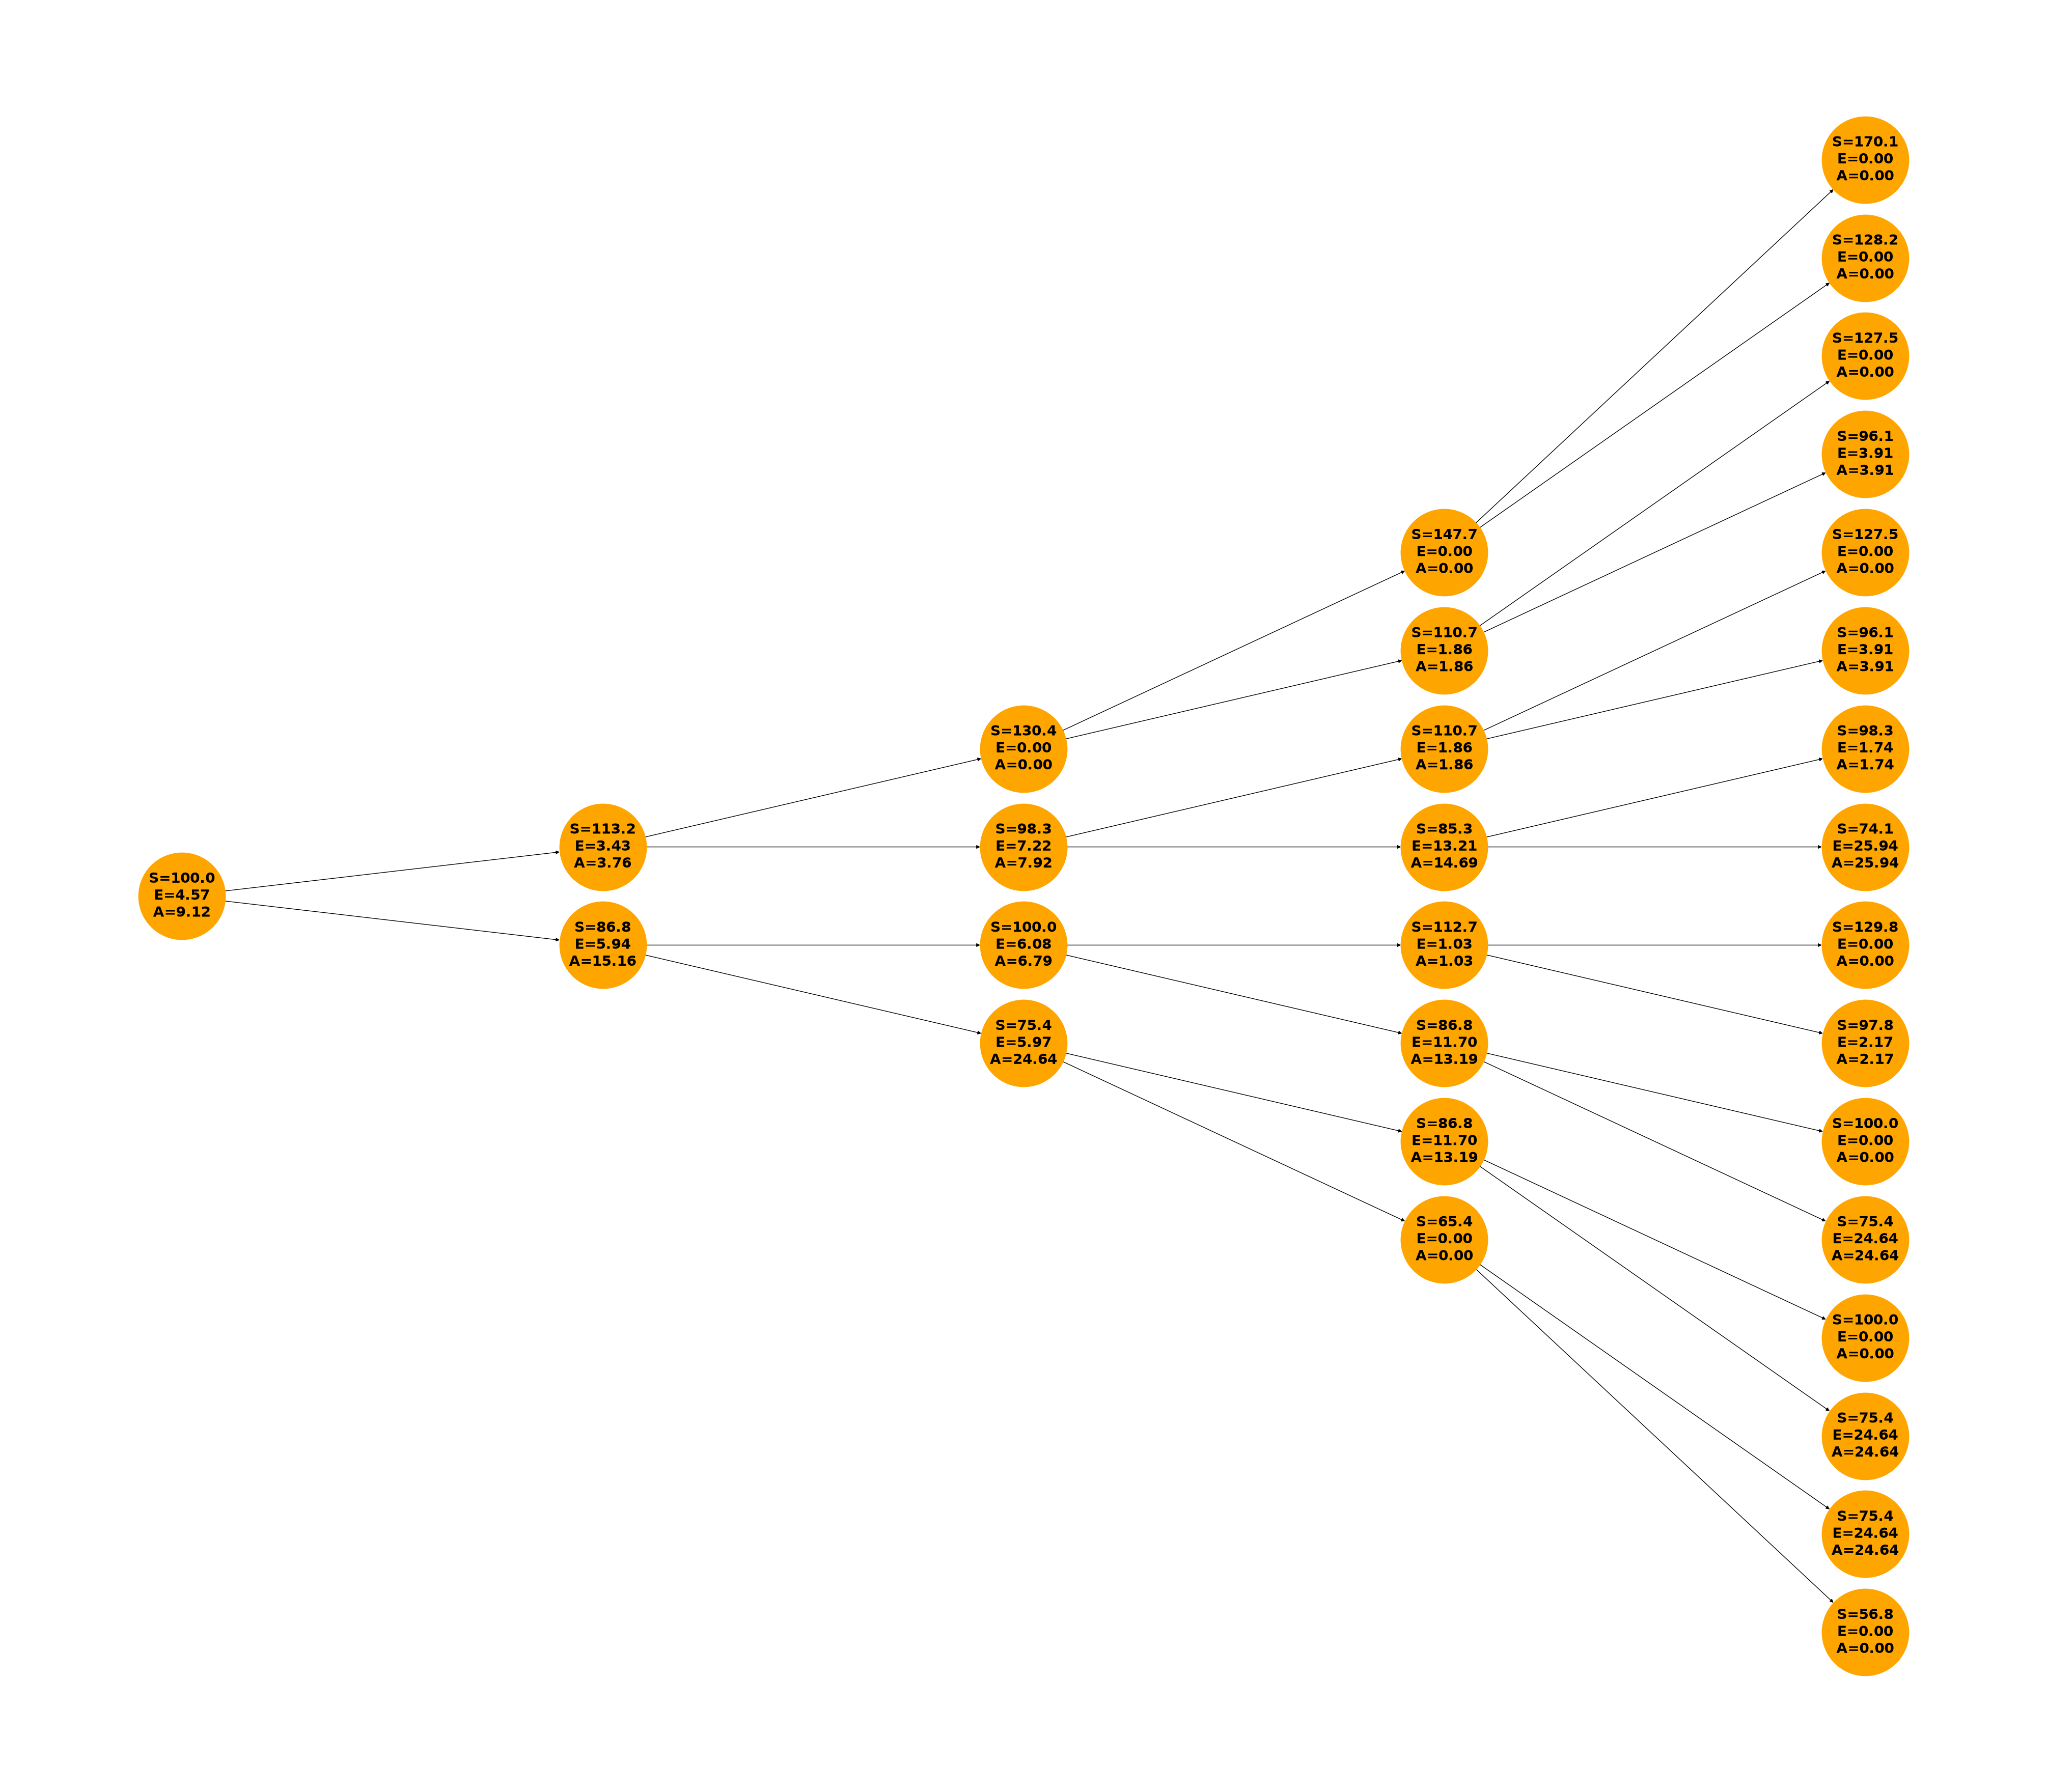

In [19]:
S_0 = 100
K = 100
rf = 0.03
sigma = 0.2
T = 2
N = 4
div_schedule = {1: 2.0, 3: 2.5}

# knock-out barriers
L = 70
U = 130

S_tree, u, d, p, df = stock_tree(S_0, rf, sigma, T, N, div_schedule, div_threshold=100)

V_euro_KO = euro_put_KO_values(S_tree, K, p, df, N, L, U)
V_amer_KO = american_put_KO_values(S_tree, K, p, df, N, L, U)

print(f" European Knock-Out Put = ${V_euro_KO[0]['']:.4f}")
print(f"American Knock-Out Put = ${V_amer_KO[0]['']:.4f}")
plot_binomial_tree(S_tree, V_euro_KO, V_amer_KO)

## 1.4 Trinomial Tree
- S = 100
- K=100
- Rf = 3%
- $\sigma$= 20%;
- T = 3 Year Annual time steps (3 Time Steps)
- No dividends

#### a) European and American Value of a Put option of Trinomial?

A recombining trinomial lattice with annual steps:

$$u = e^{\sigma\sqrt{3\Delta t}}, \qquad m = 1, \qquad d = \frac{1}{u},$$

$$p_u = \frac{1}{6} + \sqrt{\frac{\Delta t}{12\sigma^{2}}}\left(r - \frac{\sigma^{2}}{2}\right), \qquad p_m = \frac{2}{3}, \qquad p_d = \frac{1}{6} - \sqrt{\frac{\Delta t}{12\sigma^{2}}}\left(r - \frac{\sigma^{2}}{2}\right).$$

Backward induction mirrors the binomial case, with the American put
taking the larger of continuation and intrinsic value at each node.

In [20]:
def trinomial_stock_tree(S_0, r, sigma, T, N):
    dt = T / N
    df = np.exp(-r * dt)

    u = np.exp(sigma * np.sqrt(3 * dt))
    d = 1 / u
    m = 1.0
    pu = np.sqrt(dt / (12 * sigma**2)) * (r - 0.5 * sigma**2) + 1/6
    pm = 2/3
    pd = -np.sqrt(dt / (12 * sigma**2)) * (r - 0.5 * sigma**2) + 1/6

    # recombining trinomial tree indexed by (t, j)
    S = {}
    S[0] = {0: S_0}

    for t in range(1, N + 1):
        S[t] = {}
        for j in range(-2*t, 2*t + 1, 2):
            S[t][j] = S_0 * (u ** (j // 2))
    return S, u, m, d, pu, pm, pd, df

def euro_put_trinomial(S, K, pu, pm, pd, df, N):
    V = {}
    # terminal payoff
    V[N] = {}
    for j, S_T in S[N].items():
        V[N][j] = max(K - S_T, 0.0)
    # backward induction
    for t in range(N - 1, -1, -1):
        V[t] = {}
        for j in S[t]:
            V[t][j] = df * (
                pu * V[t + 1][j + 2] +
                pm * V[t + 1][j] +
                pd * V[t + 1][j - 2]
            )
    return V

def american_put_trinomial(S, K, pu, pm, pd, df, N):
    V = {}
    # terminal payoff
    V[N] = {}
    for j, S_T in S[N].items():
        V[N][j] = max(K - S_T, 0.0)
    # backward induction with early exercise
    for t in range(N - 1, -1, -1):
        V[t] = {}
        for j, S_t in S[t].items():
            continuation = df * (
                pu * V[t + 1][j + 2] +
                pm * V[t + 1][j] +
                pd * V[t + 1][j - 2]
            )
            exercise = max(K - S_t, 0.0)
            V[t][j] = max(continuation, exercise)
    return V

def plot_trinomial_tree(tree, V_euro, V_amer):
    import networkx as nx
    import matplotlib.pyplot as plt

    G = nx.DiGraph()
    labels = {}
    pos = {}

    y_gap = 2.5
    x_gap = 2.0

    for t, nodes in tree.items():
        js = sorted(nodes.keys())
        n = len(js)
        y_start = -y_gap * (n - 1) / 2  # center vertically

        for i, j in enumerate(js):
            node = (t, j)
            G.add_node(node)

            x = t * x_gap
            y = y_start + i * y_gap
            pos[node] = (x, y)

            S = nodes[j]
            labels[node] = (
                f"S={S:.1f}\n"
                f"E={V_euro[t][j]:.2f}\n"
                f"A={V_amer[t][j]:.2f}"
            )

            # connect to parents
            if t > 0:
                for parent_j in (j - 2, j, j + 2):
                    if parent_j in tree[t - 1]:
                        G.add_edge((t - 1, parent_j), node)

    plt.figure(figsize=(40, 35))
    nx.draw(
        G, pos,
        node_size=15000,
        node_color="orange",
        edge_color="black",
        linewidths=1.2,
        with_labels=False
    )
    nx.draw_networkx_labels(
        G, pos, labels,
        font_size=20,
        font_weight="bold",
        font_color="black"
    )

    plt.axis("off")
    plt.show()



u = 1.4140, m = 1.0000, d = 0.7072
pu = 0.1811, pm = 0.6667, pd = 0.1522
df = 0.9704
European Put Trinomial = $8.0939
American Put Trinomial = $9.0463


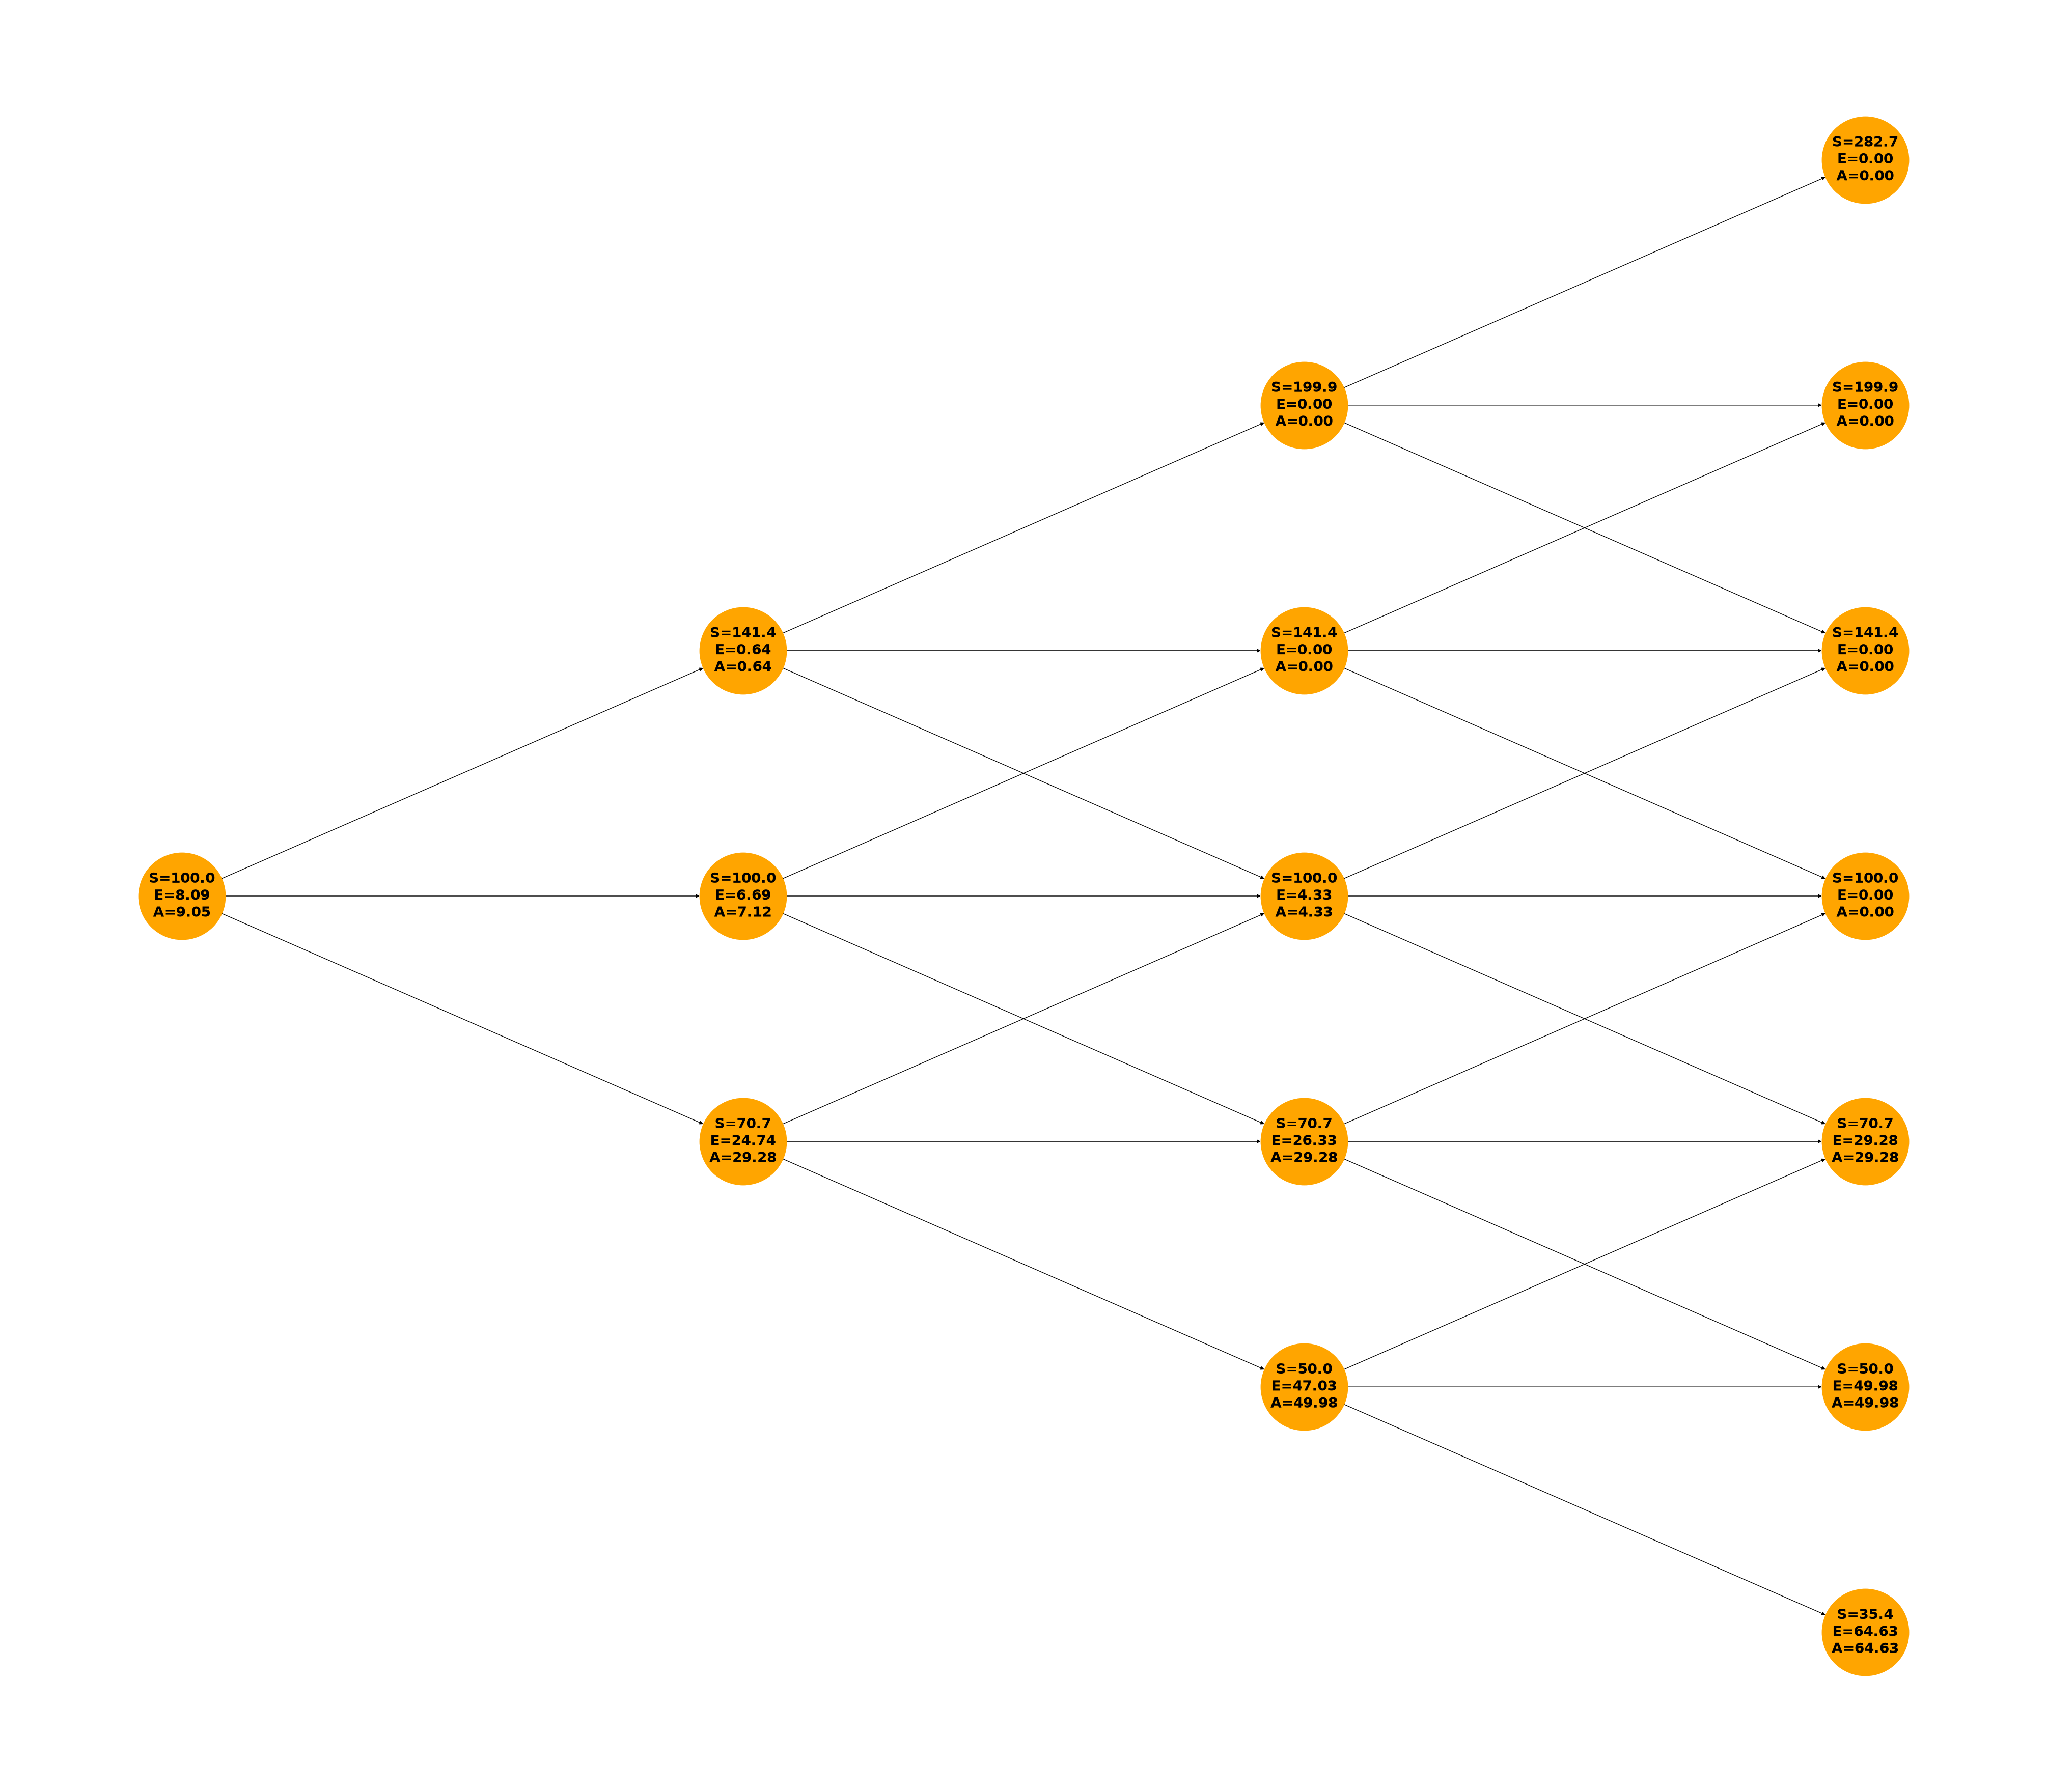

In [21]:
S_0 = 100
K = 100
rf = 0.03
sigma = 0.2
T = 3
N = 3

S, u, m, d, pu, pm, pd, df = trinomial_stock_tree(S_0, rf, sigma, T, N)

V_euro = euro_put_trinomial(S, K, pu, pm, pd, df, N)
V_amer = american_put_trinomial(S, K, pu, pm, pd, df, N)

print(f"u = {u:.4f}, m = {m:.4f}, d = {d:.4f}")
print(f"pu = {pu:.4f}, pm = {pm:.4f}, pd = {pd:.4f}")
print(f"df = {df:.4f}")

print(f"European Put Trinomial = ${V_euro[0][0]:.4f}")
print(f"American Put Trinomial = ${V_amer[0][0]:.4f}")

plot_trinomial_tree(S, V_euro, V_amer)

#### b) Compare the value to the binomial model with 3 steps and to the analytical binomial model with 10, 100, 1000 steps

The analytical benchmark evaluates the European put in closed form by
summing the binomial distribution over terminal nodes:

$$V = e^{-rT} \sum_{k=0}^{N} \binom{N}{k}\, p^{k} (1-p)^{N-k}\, \max\left(K - S_0 u^{k} d^{N-k},\; 0\right).$$

At three steps the trinomial and binomial prices bracket the converged
value from opposite sides, and refining the binomial through 10, 100, and
1,000 steps shows it settling toward the continuous-time Black-Scholes
limit.

In [22]:
def euro_put_binomial_analytical(S_0, K, rf, sigma, T, N):
    dt = T / N
    u = np.exp(sigma * np.sqrt(dt))
    d = 1 / u
    p = (np.exp(rf * dt) - d) / (u - d)
    price = 0.0
    for k in range(N + 1):
        # stock price at maturity
        S_T = S_0 * (u ** k) * (d ** (N - k))
        # payoff
        payoff = max(K - S_T, 0)
        # binomial probability
        prob = math.comb(N, k) * (p ** k) * ((1 - p) ** (N - k))
        price += payoff * prob
    value = np.exp(-rf * T) * price
    return value, u ,d, p

S_0 = 100
K = 100
rf = 0.03
sigma = 0.2
T = 3

for N in [3, 10, 100, 1000]:
    price, u ,d, p = euro_put_binomial_analytical(S_0, K, rf, sigma, T, N)
    print(f"Binomial CRR (N={N}): European Put = ${price:.4f}")
    print(f"For N = {N}: u = {u:.4f}; d = {d:.4f}, p = {p:.4f}\n")


Binomial CRR (N=3): European Put = $10.2734
For N = 3: u = 1.2214; d = 0.8187, p = 0.5258

Binomial CRR (N=10): European Put = $8.9584
For N = 10: u = 1.1158; d = 0.8962, p = 0.5138

Binomial CRR (N=100): European Put = $9.2588
For N = 100: u = 1.0352; d = 0.9660, p = 0.5043

Binomial CRR (N=1000): European Put = $9.2893
For N = 1000: u = 1.0110; d = 0.9891, p = 0.5014

